<a href="https://colab.research.google.com/github/nuraini2502/MachineLearning/blob/Praktikum11/praktikumMandiri.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

Nama : Nuraini

NIM : 0110222170

Matkul : Machine Learning | Sesi Pagi

Import Library

In [ ]:
# Memanggil library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import geopandas as gpd
import contextily as ctx

from folium.plugins import HeatMap
from mpl_toolkits.axes_grid1 import make_axes_locatable
from shapely import wkt

folium => Membuat peta interaktif berbasis Leaflet untuk menampilkan data spasial.

HeatMap
(folium.plugins) => Membuat peta sebaran panas (heatmap) dari titik koordinat.

geopandas (gpd) => Mengelola data spasial (geometri) seperti titik, garis, dan poligon.

contextily (ctx) => Menambahkan peta dasar (basemap) pada visualisasi geospasial.

make_axes_locatable => Mengatur posisi colorbar agar sejajar dengan peta.

shapely.wkt => Mengonversi data geometri (dalam format teks MULTIPOLYGON) menjadi objek spasial yang bisa digambar.

Loading Data

In [ ]:
# Mengambil data pada google drive
from google.colab import drive
drive.mount('/content/gdrive')
df = pd.read_csv('/content/gdrive/MyDrive/MachineLearning/Praktikum/data/week11/data_wisata_bogor_final.csv')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


Kode ini berfungsi untuk menghubungkan Google Colab dengan Google Drive, sehingga file yang tersimpan di dalam Drive bisa dibaca oleh notebook. Setelah drive terhubung ke folder /content/gdrive, dataset yang kamu simpan sebelumnya dibaca menggunakan pd.read_csv() dan hasilnya disimpan dalam variabel df. Dengan begitu, seluruh isi file CSV kini sudah masuk ke memori dan siap dianalisis.

In [ ]:
  # Menampilkan 5 baris pertama pada data
df.head()

,nama_tempat_wisata,kategori,preferensi,kecamatan,kabupaten_kota,rating,jumlah_rating,harga_tiket,link,latitude,longitude,link_gambar
0,Kolam renang pancar,Rekreasi,Wisata Rekreasi,Babakan Madang,Kabupaten Bogor,4.2,58.0,NaN,https://www.google.com/maps/place/Kolam+renang...,-6.574515,106.912986,https://lh3.googleusercontent.com/gps-cs-s/AG0...
1,Wisata Edukasi TK SD di Bogor,Budaya,Wisata Budaya & Edukasi,Babakan Madang,Kabupaten Bogor,4.9,1615.0,NaN,https://www.google.com/maps/place/Wisata+Eduka...,-6.575724,106.840356,https://lh3.googleusercontent.com/p/AF1QipP9Ol...
2,Curug Cibaliung Jonggol,Alam,Wisata Alam,Babakan Madang,Kabupaten Bogor,4.6,749.0,NaN,https://www.google.com/maps/place/Curug+Cibali...,-6.599597,106.958568,https://lh3.googleusercontent.com/p/AF1QipOvrJ...
3,Gunung Pancar Tour Wisata Hot Spring Water,Alam,Wisata Alam,Babakan Madang,Kabupaten Bogor,3.6,506.0,NaN,https://www.google.com/maps/place/Gunung+Panca...,-6.580854,106.904627,https://lh3.googleusercontent.com/gps-cs-s/AG0...
4,Wisata Bukit Domba,Alam,Wisata Alam,Babakan Madang,Kabupaten Bogor,4.6,476.0,NaN,https://www.google.com/maps/place/Wisata+Bukit...,-6.624837,106.906346,https://lh3.googleusercontent.com/gps-cs-s/AG0...


Fungsi ini digunakan untuk melihat lima baris pertama dari dataset. Tujuannya untuk memastikan bahwa file terbaca dengan benar dan memberikan gambaran awal mengenai struktur, isi kolom, dan karakteristik data.

In [ ]:
# Menampilkan informasi struktur dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2842 entries, 0 to 2841
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   nama_tempat_wisata  2842 non-null   object 
 1   kategori            2842 non-null   object 
 2   preferensi          2842 non-null   object 
 3   kecamatan           2842 non-null   object 
 4   kabupaten_kota      2842 non-null   object 
 5   rating              2779 non-null   float64
 6   jumlah_rating       2779 non-null   float64
 7   harga_tiket         0 non-null      float64
 8   link                2842 non-null   object 
 9   latitude            2842 non-null   float64
 10  longitude           2842 non-null   float64
 11  link_gambar         2585 non-null   object 
dtypes: float64(5), object(7)
memory usage: 266.6+ KB


Kode ini menampilkan informasi detail mengenai dataset, termasuk tipe data di setiap kolom, jumlah baris yang terisi, dan apakah terdapat nilai yang hilang. Informasi ini sangat penting sebagai langkah awal sebelum melakukan pembersihan data atau preprocessing

Data Cleaning

In [ ]:
# Mengecek jumlah data kosong (NaN) di setiap kolom pada DataFrame
df.isnull().sum()

,0
nama_tempat_wisata,0
kategori,0
preferensi,0
kecamatan,0
kabupaten_kota,0
rating,63
jumlah_rating,63
harga_tiket,2842
link,0
latitude,0


Kode ini digunakan untuk memeriksa apakah ada nilai kosong atau missing value pada setiap kolom dalam dataset. Hasilnya akan menunjukkan jumlah data yang hilang per kolom sehingga kamu bisa menentukan perlakuan yang diperlukan, seperti mengisi nilai atau membuang kolom.

In [92]:
# Menduplikat data
df.duplicated().sum()

np.int64(0)

Kode ini mengecek apakah terdapat baris data yang duplikat. Jika ada nilai lebih dari nol, berarti ada baris yang muncul lebih dari sekali dan mungkin perlu dihapus agar tidak memengaruhi hasil analisis.

Exploratory Data Analysis

In [93]:
# Visualisasi Heatmap Sebaran

# Buat list data dari latitude dan longitude untuk heatmap
m = folium.Map(location=[df['latitude'].mean(), df['longitude'].mean()], zoom_start=11)

# Menambahkan headmap ke peta
heat_data = df[['latitude','longitude']].dropna().values.tolist()
HeatMap(heat_data).add_to(m)
# Menampilkan peta
m

Kode ini membuat peta interaktif menggunakan Folium dan menampilkan heatmap berdasarkan titik lokasi wisata. Pertama, peta dipusatkan di wilayah Bogor. Kemudian, semua data latitude dan longitude diambil dan dijadikan daftar koordinat. HeatMap kemudian memproyeksikan titik-titik tersebut menjadi peta panas untuk menunjukkan area dengan kepadatan titik wisata tertinggi.

In [ ]:
numerics = df.select_dtypes(include=['float64','int64'])
from scipy.stats import shapiro

stat, p = shapiro(numerics)
print("p-value:", p)

p-value: nan


Bagian ini mengambil seluruh kolom numerik dari dataset, kemudian menjalankan uji normalitas menggunakan Shapiro–Wilk. Tujuan dari uji ini adalah untuk mengetahui apakah distribusi data numerik mengikuti distribusi normal atau tidak. Hasil p-value kemudian digunakan sebagai dasar pemilihan teknik korelasi dan scaling selanjutnya. Jika p-value kecil dari 0.05, data dianggap tidak normal sehingga lebih cocok diproses menggunakan teknik non-parametrik seperti Spearman correlation dan RobustScaler.

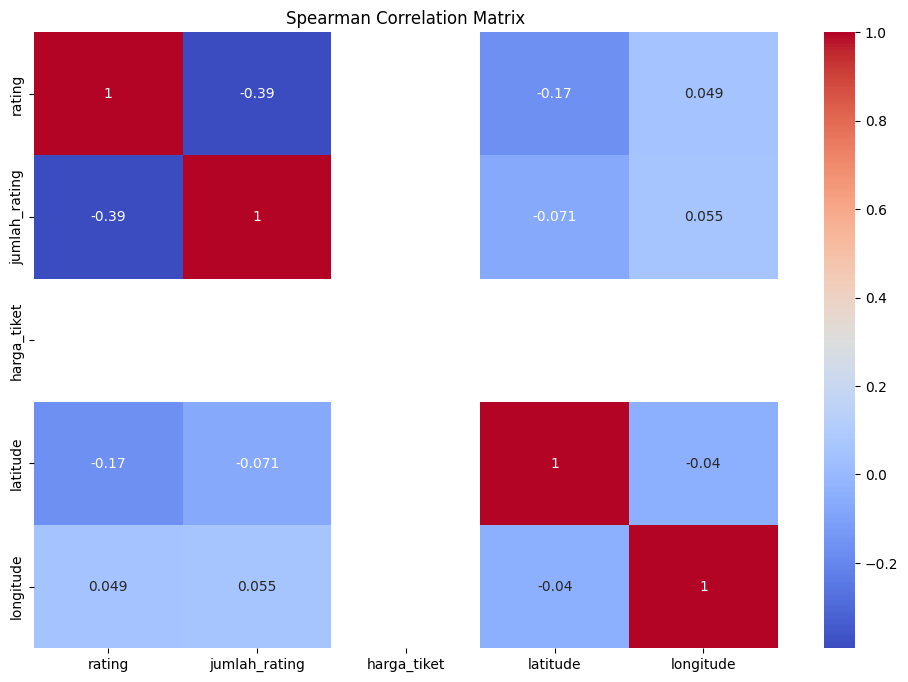

In [ ]:
corr = numerics.corr(method='spearman')

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Spearman Correlation Heatmap")
plt.show()

Kode ini menghitung hubungan antar variabel numerik menggunakan metode Spearman karena data tidak berdistribusi normal. Korelasi kemudian divisualisasikan menggunakan heatmap agar hubungan antar variabel dapat terlihat lebih jelas. Warna yang lebih terang atau lebih gelap menunjukkan kekuatan korelasi, baik positif maupun negatif.

In [ ]:
X = numerics.copy()
# Drop the 'harga_tiket' column as it contains only NaN values
X = X.drop('harga_tiket', axis=1)

# Drop rows with any remaining NaN values (e.g., from 'rating' or 'jumlah_rating')
X = X.dropna()

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

,rating,jumlah_rating,latitude,longitude
0,-0.75,-0.061856,0.038071,0.558451
1,1.00,1.944588,0.030460,0.209330
2,0.25,0.828608,-0.119850,0.777558
3,-2.25,0.515464,-0.001838,0.518269
4,0.25,0.476804,-0.278761,0.526532


Pada bagian kode ini, data numerik yang sebelumnya telah dipilih disalin ke variabel baru bernama X agar tidak mengubah data asli. Kolom harga_tiket kemudian dihapus karena berisi nilai kosong seluruhnya sehingga tidak memberikan kontribusi pada analisis. Setelah itu, baris-baris yang masih memiliki nilai kosong pada kolom lain seperti rating atau jumlah_rating dibuang supaya proses scaling dan clustering tidak mengalami error. Data yang sudah bersih kemudian dinormalisasi menggunakan RobustScaler, yaitu metode scaling yang tahan terhadap outlier. Hasil scaling ini dikembalikan lagi dalam bentuk DataFrame dengan nama kolom yang sama seperti sebelumnya sehingga mudah dibaca dan digunakan pada proses analisis berikutnya.

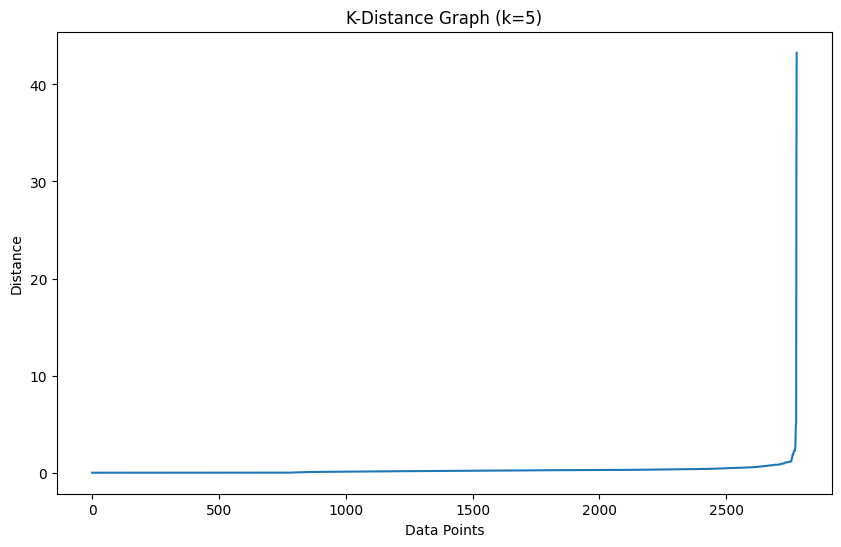

In [ ]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import RobustScaler

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:,4])
plt.figure(figsize=(10,6))
plt.plot(distances)
plt.title("K-Distance Graph (k=5)")
plt.ylabel("Distance")
plt.xlabel("Data Points")
plt.show()

Kode ini membuat grafik yang disebut K-Distance Graph untuk membantu menentukan parameter eps pada DBSCAN. Pertama, dibuat model NearestNeighbors untuk mencari 5 tetangga terdekat tiap titik data, lalu model ini dilatih dengan data X_scaled. Selanjutnya, jarak ke 5 tetangga terdekat tiap titik dihitung dan jarak ke tetangga ke-5 diambil, kemudian diurutkan. Terakhir, jarak yang sudah diurutkan ini diplot menggunakan matplotlib sehingga terlihat grafik K-Distance, yang nantinya bisa digunakan untuk menentukan jarak ambang (eps) saat menjalankan DBSCAN.

In [91]:
from sklearn.cluster import DBSCAN
db = DBSCAN(eps=0.35, min_samples=5)
db_labels = db.fit_predict(X_scaled)

cluster_series = pd.Series(db_labels, index=X.index)

df['Cluster'] = cluster_series
df['Cluster'].value_counts()

,count
Cluster,
0.0,1844
-1.0,349
51.0,27
54.0,18
2.0,18
...,...
63.0,5
67.0,5
65.0,5


Kode ini menjalankan algoritma DBSCAN untuk mengelompokkan data. Pertama, dibuat objek DBSCAN dengan parameter eps=0.35 (jarak maksimum agar titik dianggap tetangga) dan min_samples=5 (jumlah minimum tetangga untuk membentuk cluster). Kemudian, fit_predict(X_scaled) digunakan untuk mempelajari data dan memberi label cluster ke tiap titik; hasilnya berupa array label cluster. Label ini diubah menjadi pd.Series agar sesuai dengan indeks data asli, lalu ditambahkan ke dataframe df sebagai kolom Cluster. Terakhir, df['Cluster'].value_counts() menampilkan jumlah titik di tiap cluster, termasuk titik yang dianggap outlier (biasanya diberi label -1).

In [90]:
from sklearn.metrics import silhouette_score

non_noise_mask = db_labels != -1
X_for_silhouette = X_scaled[non_noise_mask]
labels_for_silhouette = db_labels[non_noise_mask]
sil = silhouette_score(X_for_silhouette, labels_for_silhouette)
sil

np.float64(-0.08677849759993464)

Kode ini menghitung Silhouette Score untuk menilai kualitas clustering DBSCAN, tapi hanya untuk titik yang bukan outlier. Pertama, dibuat mask untuk memilih data yang bukan noise (db_labels != -1). Data dan label yang sudah difilter ini disimpan di X_for_silhouette dan labels_for_silhouette. Fungsi silhouette_score kemudian menghitung skor, yang menunjukkan seberapa rapat tiap cluster dan seberapa jelas pemisahannya: nilai mendekati 1 berarti clustering bagus, nilai mendekati 0 berarti cluster saling tumpang tindih, dan nilai negatif berarti ada cluster yang salah penempatan. Hasil akhirnya disimpan di variabel sil.

In [86]:
df['Cluster_Desc'] = df['Cluster'].map({
    0: "Baik",
    1: "Kurang",
    -1: "Noise"
})

df[['Cluster','Cluster_Desc']].head()

,Cluster,Cluster_Desc
0,0.0,Baik
1,1.0,Kurang
2,0.0,Baik
3,-1.0,Noise
4,0.0,Baik


Kode ini menambahkan kolom Cluster_Desc ke dataframe df untuk memberi deskripsi lebih mudah dimengerti dari hasil clustering DBSCAN. Label numerik di kolom Cluster (misal 0, 1, -1) diubah menjadi teks: 0 menjadi "Baik", 1 menjadi "Kurang", dan -1 menjadi "Noise" untuk menandai outlier. Bagian terakhir df[['Cluster','Cluster_Desc']].head() menampilkan 5 baris pertama dari kolom Cluster dan Cluster_Desc supaya bisa dicek hasil pemetaan label ke deskripsi.

In [87]:
summary = df.groupby('Cluster_Desc').mean(numeric_only=True)
summary

,rating,jumlah_rating,harga_tiket,latitude,longitude,Cluster,PC1,PC2
Cluster_Desc,,,,,,,,
Baik,4.600542,123.162148,NaN,-6.573115,106.796082,0.0,-1.764929,0.258591
Kurang,4.900000,1615.000000,NaN,-6.575724,106.840356,1.0,0.157165,1.010660
Noise,4.219484,2869.295129,NaN,-6.558052,106.820003,-1.0,1.776155,-0.677503


In [89]:
import plotly.express as px

fig = px.scatter(
    df,
    x='PC1',
    y='PC2',
    color='Cluster_Desc',
    hover_data=['nama_tempat_wisata'],
    title="Visualisasi Interaktif – Hasil Clustering DBSCAN"
)
fig.show()

Kode ini membuat visualisasi interaktif hasil clustering DBSCAN menggunakan Plotly Express. Dataframe df diplot sebagai scatter plot dengan sumbu PC1 dan PC2 (biasanya hasil reduksi dimensi, misal PCA). Titik-titik diberi warna sesuai kolom Cluster_Desc sehingga cluster berbeda terlihat jelas. Saat kursor diarahkan ke titik, muncul informasi tambahan dari kolom nama_tempat_wisata. fig.show() menampilkan plot interaktif di browser atau notebook, memungkinkan zoom, hover, dan eksplorasi data secara mudah.